# Give Me Some Credit

## Import libraries, functions and data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import numpy as np
import jax
import jax.numpy as jnp

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score
from xgboost import XGBClassifier

from google.colab import drive

In [2]:
def plot_roc_curve(fpr, tpr, label="ROC Curve"):
    plt.figure(figsize=(6, 6))

    plt.plot(fpr, tpr, label=label)
    plt.plot([0, 1], [0, 1], color='red', linestyle='--')

    plt.axis([0, 1, 0, 1])
    plt.xlabel("False Positive Rate (1 - SPECIFICITY)")
    plt.ylabel("True Positive Rate (SENSITIVITY)")
    plt.title(label)

    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

In [3]:
drive.mount('/content/drive')
path = "/content/drive/MyDrive/Colab Notebooks/NAML/Project/data/"

train_df = pd.read_csv(path + "cs-training.csv")
test_df = pd.read_csv(path + "cs-test.csv")

Mounted at /content/drive


## Exploratory data analysis

In [4]:
train_df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [5]:
test_df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,NaN,0.885519,43,0,0.177513,5700.0,4,0,0,0,0.0
1,2,NaN,0.463295,57,0,0.527237,9141.0,15,0,4,0,2.0
2,3,NaN,0.043275,59,0,0.687648,5083.0,12,0,1,0,2.0
3,4,NaN,0.280308,38,1,0.925961,3200.0,7,0,2,0,0.0
4,5,NaN,1.000000,27,0,0.019917,3865.0,4,0,0,0,1.0


In [6]:
train_df.rename(columns={'Unnamed: 0':'ID'}, inplace=True)
test_df.rename(columns={'Unnamed: 0':'ID'}, inplace=True)

In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   ID                                    150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

In [8]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101503 entries, 0 to 101502
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   ID                                    101503 non-null  int64  
 1   SeriousDlqin2yrs                      0 non-null       float64
 2   RevolvingUtilizationOfUnsecuredLines  101503 non-null  float64
 3   age                                   101503 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  101503 non-null  int64  
 5   DebtRatio                             101503 non-null  float64
 6   MonthlyIncome                         81400 non-null   float64
 7   NumberOfOpenCreditLinesAndLoans       101503 non-null  int64  
 8   NumberOfTimes90DaysLate               101503 non-null  int64  
 9   NumberRealEstateLoansOrLines          101503 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  101503 non-null  int64  
 11  

In [9]:
train_df.describe().round(decimals=2)

,ID,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,120269.00,150000.00,150000.00,150000.00,150000.00,146076.00
mean,75000.50,0.07,6.05,52.30,0.42,353.01,6670.22,8.45,0.27,1.02,0.24,0.76
std,43301.41,0.25,249.76,14.77,4.19,2037.82,14384.67,5.15,4.17,1.13,4.16,1.12
min,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,37500.75,0.00,0.03,41.00,0.00,0.18,3400.00,5.00,0.00,0.00,0.00,0.00
50%,75000.50,0.00,0.15,52.00,0.00,0.37,5400.00,8.00,0.00,1.00,0.00,0.00
75%,112500.25,0.00,0.56,63.00,0.00,0.87,8249.00,11.00,0.00,2.00,0.00,1.00
max,150000.00,1.00,50708.00,109.00,98.00,329664.00,3008750.00,58.00,98.00,54.00,98.00,20.00


In [10]:
test_df.describe().round(decimals=2)

,ID,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,101503.00,0.0,101503.00,101503.00,101503.00,101503.00,81400.00,101503.00,101503.00,101503.00,101503.00,98877.00
mean,50752.00,NaN,5.31,52.41,0.45,344.48,6855.04,8.45,0.30,1.01,0.27,0.77
std,29301.54,NaN,196.16,14.78,4.54,1632.60,36508.60,5.14,4.52,1.11,4.50,1.14
min,1.00,NaN,0.00,21.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,25376.50,NaN,0.03,41.00,0.00,0.17,3408.00,5.00,0.00,0.00,0.00,0.00
50%,50752.00,NaN,0.15,52.00,0.00,0.36,5400.00,8.00,0.00,1.00,0.00,0.00
75%,76127.50,NaN,0.56,63.00,0.00,0.85,8200.00,11.00,0.00,2.00,0.00,1.00
max,101503.00,NaN,21821.00,104.00,98.00,268326.00,7727000.00,85.00,98.00,37.00,98.00,43.00


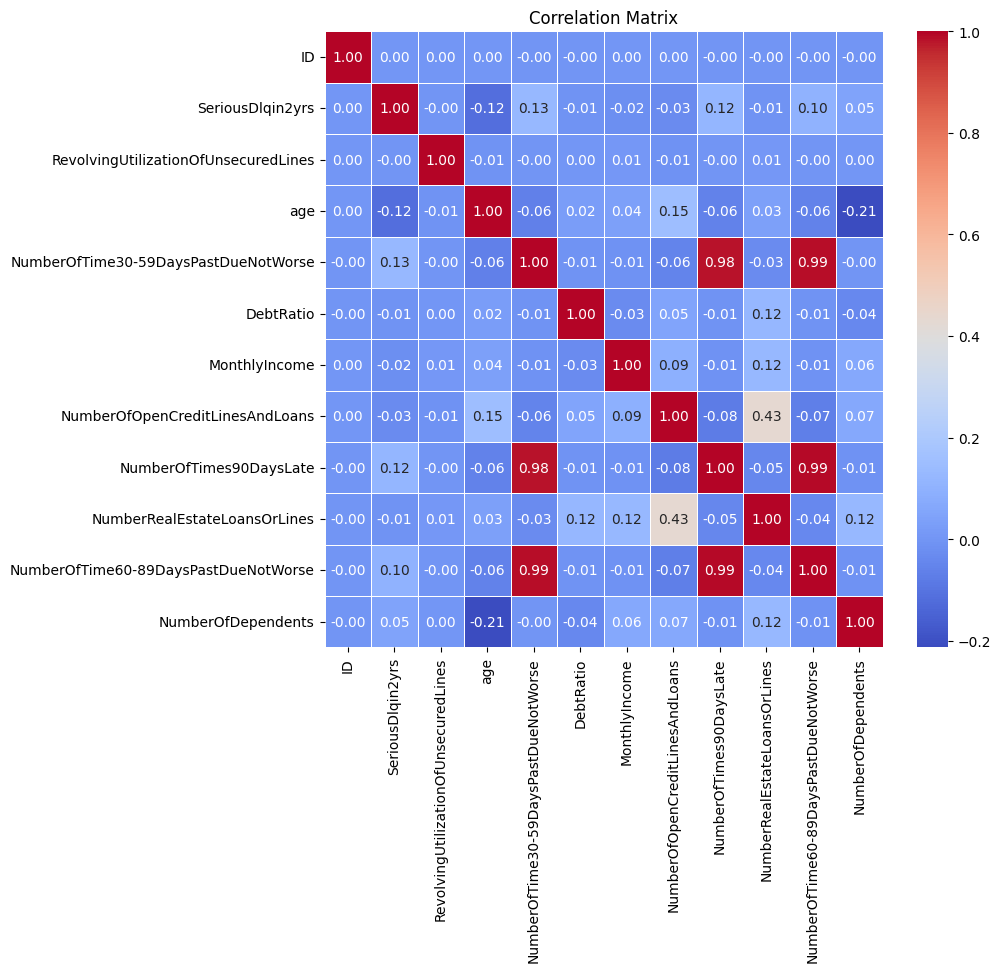

In [11]:
corr = train_df.corr()
fig = plt.figure(figsize=(9,8))
plt.title('Correlation Matrix')
ax = sns.heatmap(corr, annot=True, fmt='.2f', cmap="coolwarm", linewidths=0.5)
plt.show()

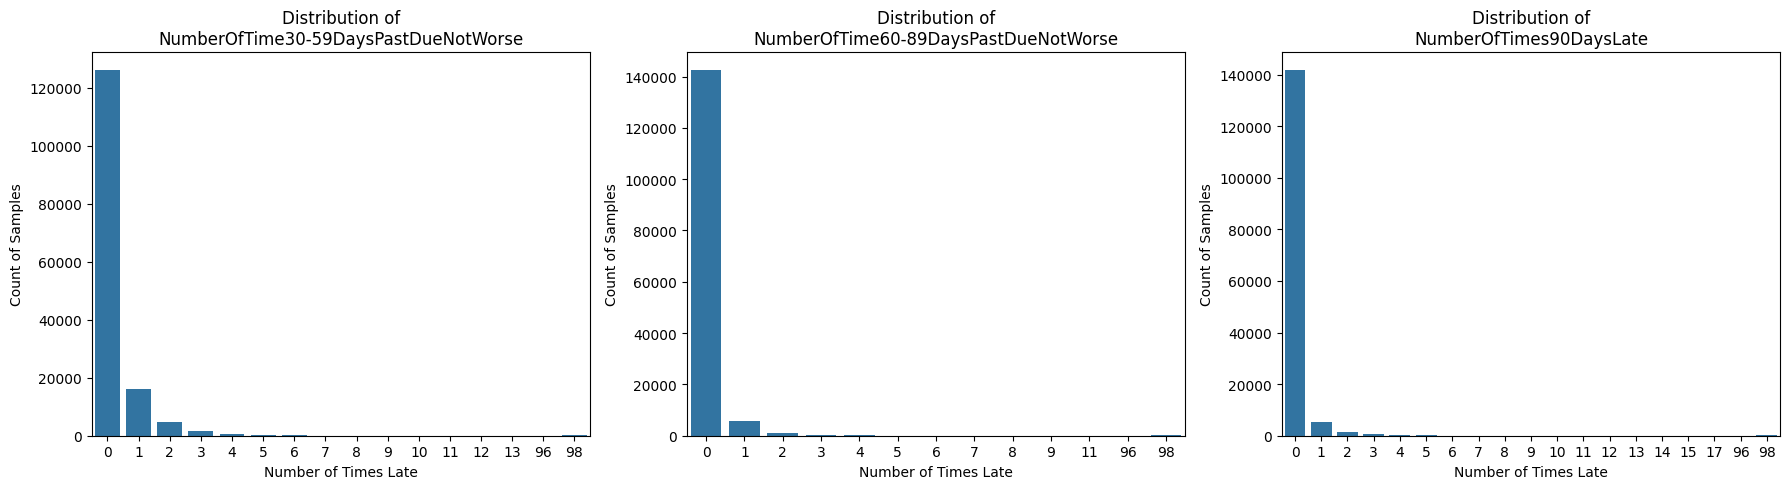

In [12]:
late_cols = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate'
]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(late_cols):
    sns.countplot(
        data=train_df,
        x=col,
        ax=axes[i]
    )
    axes[i].set_title(f'Distribution of\n{col}')
    axes[i].set_xlabel('Number of Times Late')
    axes[i].set_ylabel('Count of Samples')
plt.tight_layout()
plt.show()

In [13]:
count_age_zero = (train_df['age'] == 0).sum()
print(f"Number of samples with age = 0: {count_age_zero}")

Number of samples with age = 0: 1


In [14]:
wrong_mask = (train_df[late_cols[0]].isin([96, 98])) | \
             (train_df[late_cols[1]].isin([96, 98])) | \
             (train_df[late_cols[2]].isin([96, 98]))
wrong_samples = train_df[wrong_mask]

combinations_table = wrong_samples[late_cols].value_counts().reset_index(name='Count')
# wrong_samples[late_cols]: filtered dataset with corrupted rows only
# .value_counts(): it looks for rows that has the same three numbers and counts how many times that combination appears
# .reset_index(name='Count'): it flattens the .value_counts() output into a standard dataframe

print("There are " + str(len(wrong_samples)) + " corrupted samples:")
combinations_table.style.hide(axis="index")

There are 269 corrupted samples:


NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate,Count
98,98,98,264
96,96,96,5


In [15]:
print(train_df.duplicated().value_counts())
print(test_df.duplicated().value_counts())
# no duplicated rows (all False)

False    150000
Name: count, dtype: int64
False    101503
Name: count, dtype: int64


In [16]:
mis_val = train_df.isnull().sum()
mis_val_percent = 100 * train_df.isnull().sum() / len(train_df)
mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
mis_val_table_ren_columns = mis_val_table.rename(
columns = {0 : 'Missing Values', 1 : '% of Total Values'})
mis_val_table_ren_columns = mis_val_table_ren_columns[
    mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
'% of Total Values', ascending=False).round(1)
print ("There are " + str(mis_val_table_ren_columns.shape[0]) +
      " columns that have missing values:")
mis_val_table_ren_columns

There are 2 columns that have missing values:


,Missing Values,% of Total Values
MonthlyIncome,29731,19.8
NumberOfDependents,3924,2.6


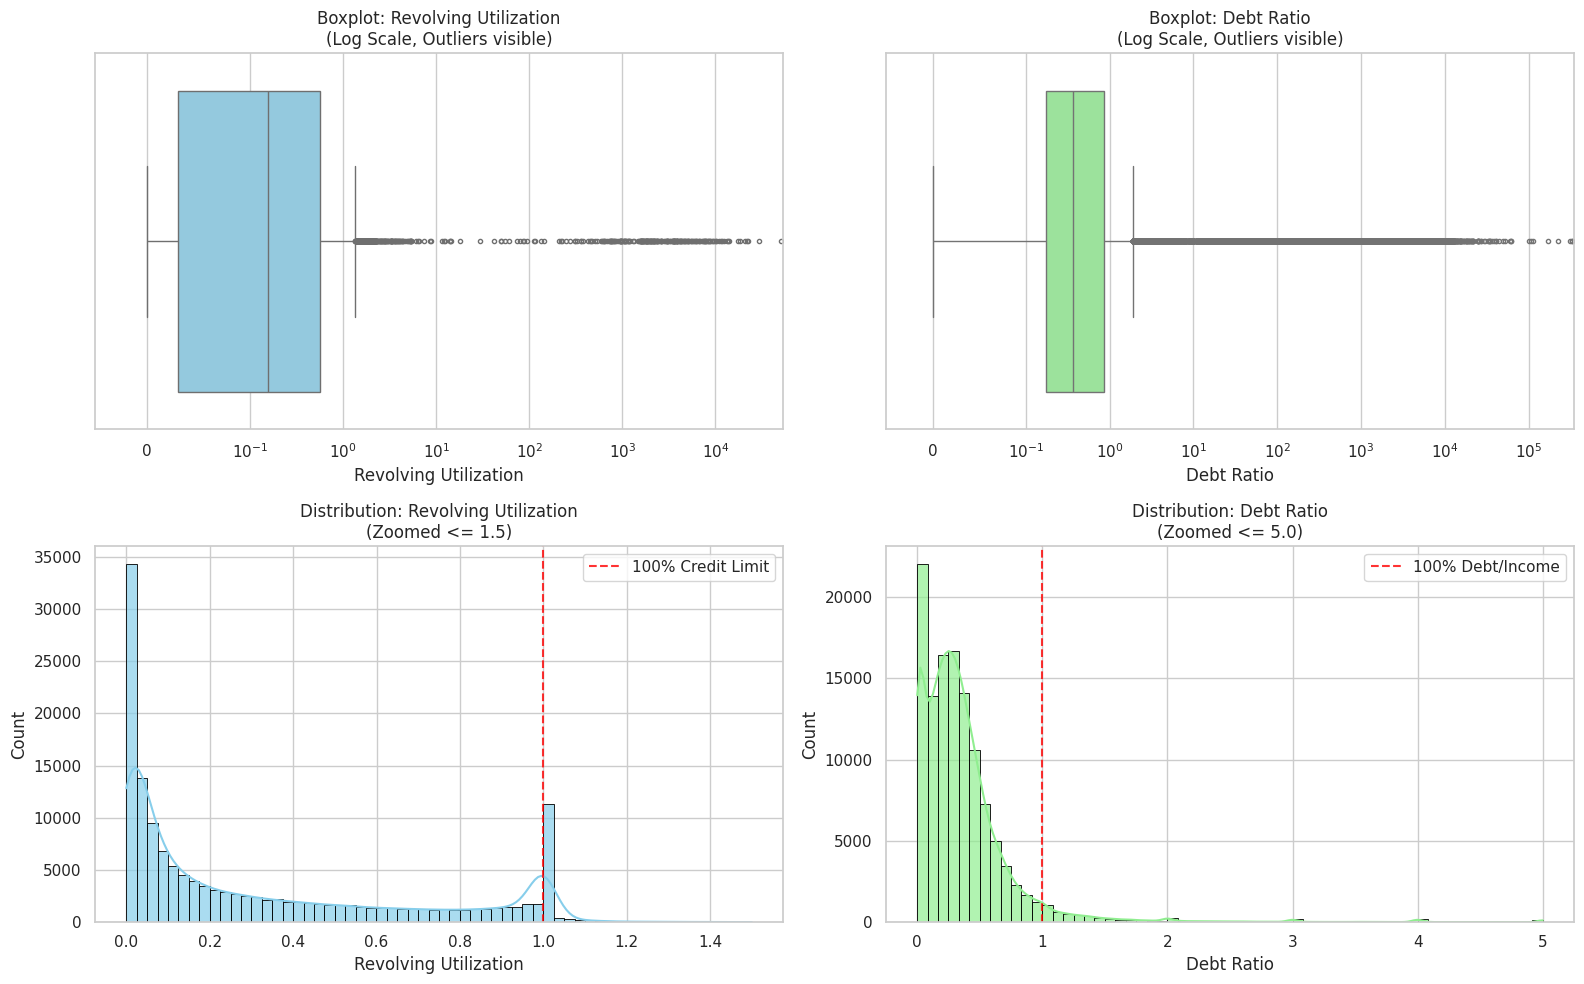

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Impostiamo un tema globale più pulito e leggibile
sns.set_theme(style="whitegrid")

# Creiamo la griglia 2x2
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# --- RIGA 1: BOXPLOT MIGLIORATI ---
# Manteniamo symlog per vedere gli outlier, ma tagliamo via la parte negativa dell'asse X

sns.boxplot(x=train_df['RevolvingUtilizationOfUnsecuredLines'], ax=axes[0, 0], color='skyblue', fliersize=3)
axes[0, 0].set_title('Boxplot: Revolving Utilization\n(Log Scale, Outliers visible)', fontsize=12)
axes[0, 0].set_xlabel('Revolving Utilization')
axes[0, 0].set_xscale('symlog', linthresh=0.1)
axes[0, 0].set_xlim(left=-0.05) # <-- Questo nasconde i numeri negativi inutili!

sns.boxplot(x=train_df['DebtRatio'], ax=axes[0, 1], color='lightgreen', fliersize=3)
axes[0, 1].set_title('Boxplot: Debt Ratio\n(Log Scale, Outliers visible)', fontsize=12)
axes[0, 1].set_xlabel('Debt Ratio')
axes[0, 1].set_xscale('symlog', linthresh=0.1)
axes[0, 1].set_xlim(left=-0.05) # <-- Come sopra


# --- RIGA 2: ISTOGRAMMI CON LINEE DI RIFERIMENTO ---
# Aggiungiamo più bin, la curva KDE anche al DebtRatio e delle linee rosse tratteggiate
# per indicare visivamente il "limite logico" di 1.0 (100%)

zoom_revolving = train_df[train_df['RevolvingUtilizationOfUnsecuredLines'] <= 1.5]['RevolvingUtilizationOfUnsecuredLines']
sns.histplot(zoom_revolving, bins=60, ax=axes[1, 0], color='skyblue', kde=True, edgecolor='black', alpha=0.7)
# Linea rossa per indicare l'uso del 100% del limite di credito
axes[1, 0].axvline(x=1.0, color='red', linestyle='--', linewidth=1.5, alpha=0.8, label='100% Credit Limit')
axes[1, 0].set_title('Distribution: Revolving Utilization\n(Zoomed <= 1.5)', fontsize=12)
axes[1, 0].set_xlabel('Revolving Utilization')
axes[1, 0].set_ylabel('Count')
axes[1, 0].legend()

zoom_debt = train_df[train_df['DebtRatio'] <= 5.0]['DebtRatio']
sns.histplot(zoom_debt, bins=60, ax=axes[1, 1], color='lightgreen', kde=True, edgecolor='black', alpha=0.7)
# Linea rossa per indicare dove il debito eguaglia esattamente il reddito (100%)
axes[1, 1].axvline(x=1.0, color='red', linestyle='--', linewidth=1.5, alpha=0.8, label='100% Debt/Income')
axes[1, 1].set_title('Distribution: Debt Ratio\n(Zoomed <= 5.0)', fontsize=12)
axes[1, 1].set_xlabel('Debt Ratio')
axes[1, 1].set_ylabel('Count')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Resettiamo il tema di seaborn al default nel caso ti serva per altri plot
# sns.reset_orig()

In [18]:
wrong_revolving = (train_df['RevolvingUtilizationOfUnsecuredLines'] > 1.0).sum()
print(f"Samples with RevolvingUtilization > 1.0: {wrong_revolving}")

Samples with RevolvingUtilization > 1.0: 3321


In [19]:
wrong_debt = (train_df['DebtRatio'] > 10.0).sum()
print(f"Campioni con DebtRatio > 10.0: {wrong_debt}")

Campioni con DebtRatio > 10.0: 28877


## Imputing and cleaning

We fix *age*, *RevolvingUtilizationOfUnsecuredLines*, *DebtRatio*

In [20]:
train_df = train_df[train_df['age'] > 0]
train_df = train_df[train_df['RevolvingUtilizationOfUnsecuredLines'] <= 2.0]
train_df = train_df[train_df['DebtRatio'] <= 10.0]

We fix *NumberOfTime30-59DaysPastDueNotWorse*, *NumberOfTime60-89DaysPastDueNotWorse* and *NumberOfTimes90DaysLate*

In [21]:
for col in late_cols:
    train_df = train_df[~train_df[col].isin([96, 98])]

We fix *MonthlyIncome* and *NumberOfDependents*

In [22]:
inc_median = train_df['MonthlyIncome'].median()
dep_median = train_df['NumberOfDependents'].median()

train_df['MonthlyIncome'] = train_df['MonthlyIncome'].fillna(inc_median)
train_df['NumberOfDependents'] = train_df['NumberOfDependents'].fillna(dep_median).astype(int)

In [23]:
print(f"New number of training samples: {len(train_df)}")

New number of training samples: 120603


## More data analysis

In [24]:
train_df.describe().round(decimals=2)

,ID,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,120603.00,120603.00,120603.00,120603.00,120603.00,120603.00,120603.00,120603.00,120603.00,120603.00,120603.00,120603.00
mean,75027.62,0.07,0.33,51.63,0.26,0.42,6758.27,8.66,0.09,1.03,0.07,0.83
std,43292.66,0.25,0.35,14.68,0.71,0.74,14334.60,5.20,0.48,1.15,0.33,1.14
min,1.00,0.00,0.00,21.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,37659.50,0.00,0.03,41.00,0.00,0.14,3500.00,5.00,0.00,0.00,0.00,0.00
50%,74977.00,0.00,0.17,51.00,0.00,0.29,5471.50,8.00,0.00,1.00,0.00,0.00
75%,112508.50,0.00,0.57,62.00,0.00,0.47,8200.00,11.00,0.00,2.00,0.00,1.00
max,150000.00,1.00,2.00,105.00,13.00,10.00,3008750.00,58.00,17.00,54.00,11.00,20.00


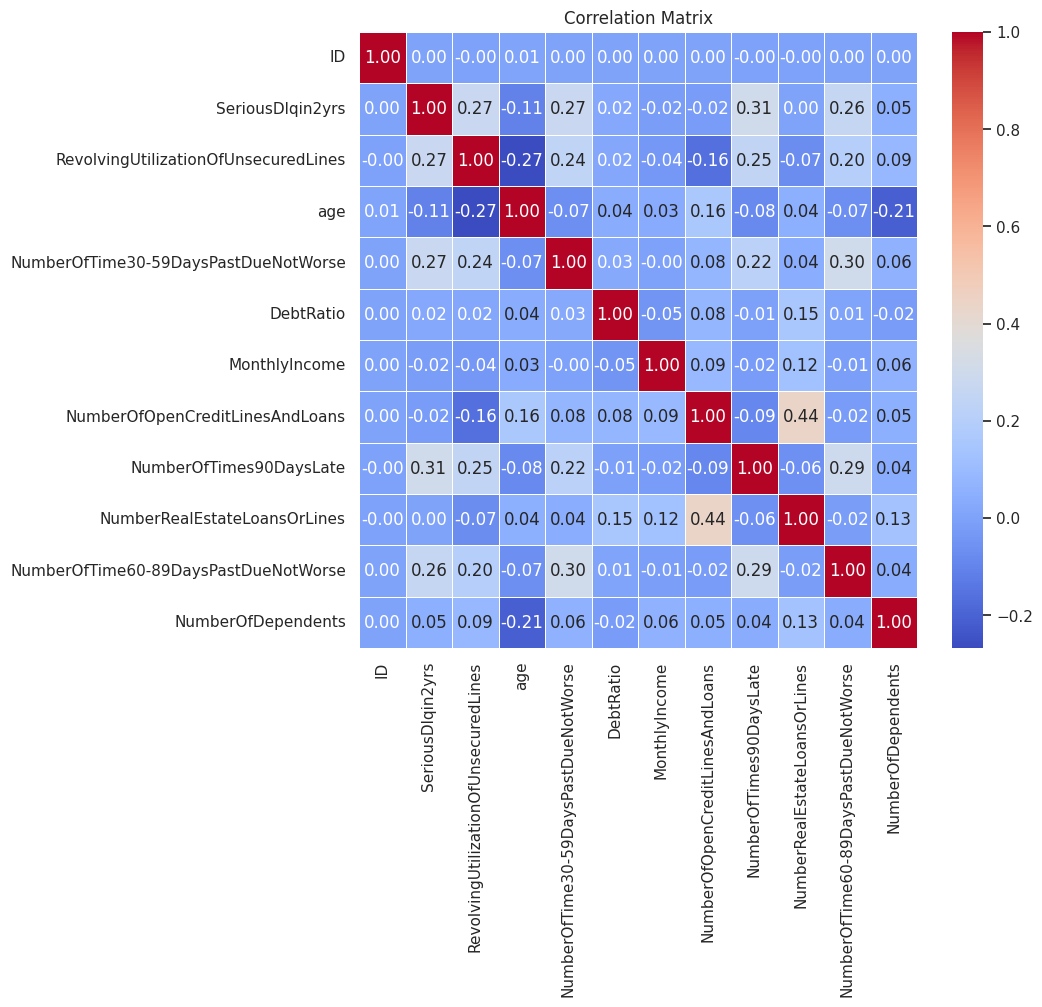

In [25]:
corr = train_df.corr()
fig = plt.figure(figsize=(9,8))
plt.title('Correlation Matrix')
ax = sns.heatmap(corr, annot=True, fmt='.2f', cmap="coolwarm", linewidths=0.5)
plt.show()

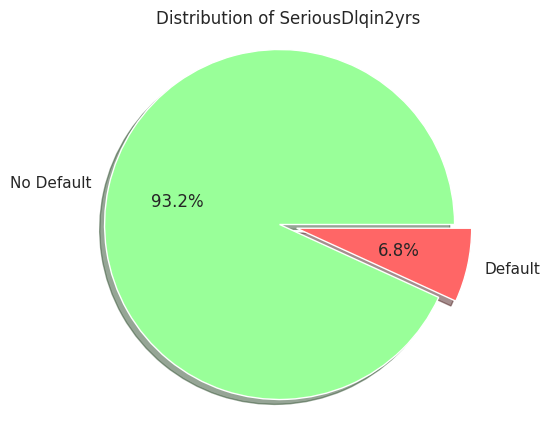

In [26]:
target_counts = train_df['SeriousDlqin2yrs'].value_counts()

plt.figure(figsize=(5, 5))
plt.pie(
    target_counts,
    labels=['No Default', 'Default'],
    autopct='%1.1f%%', # it automatically computes percentages
    colors=['#99ff99', '#ff6666'],
    explode=(0, 0.1), # highlight the Default slice
    shadow=True
)
plt.title('Distribution of SeriousDlqin2yrs')
plt.axis('equal')
plt.show()

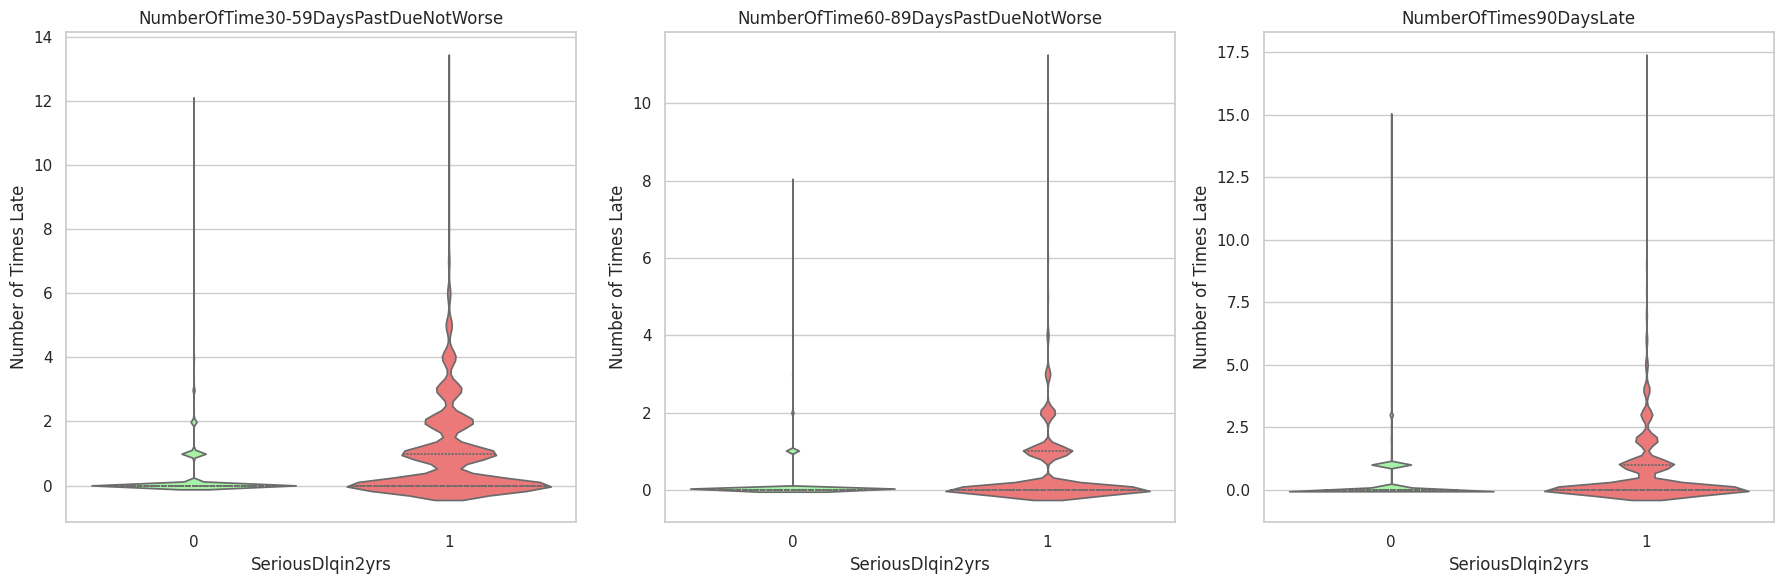

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, feature in enumerate(late_cols):
    sns.violinplot(
        data=train_df,
        x='SeriousDlqin2yrs',
        y=feature,
        ax=axes[i],
        hue='SeriousDlqin2yrs',
        palette=['#99ff99', '#ff6666'],
        inner='quartile',
        legend=False
    )
    axes[i].set_title(feature)
    axes[i].set_xlabel('SeriousDlqin2yrs')
    axes[i].set_ylabel('Number of Times Late')
plt.tight_layout()
plt.show()

In [28]:
# add some other visualizations

## Model

In [29]:
X = train_df.drop(['SeriousDlqin2yrs', 'ID'], axis=1)
y = train_df['SeriousDlqin2yrs']

W = test_df.drop(['SeriousDlqin2yrs', 'ID'], axis=1)
z = test_df['SeriousDlqin2yrs']

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=123, test_size = 0.2)

train_mean = X_train.mean(axis=0)
train_std = X_train.std(axis=0)

X_train_scaled = (X_train - train_mean) / train_std
X_test_scaled = (X_test - train_mean) / train_std

## Logistic Regression

In [31]:
# ...

## Logistic Regression with Cross Validation

In [32]:
# ...

## ANN

In [33]:
X_train_array = np.array(X_train_scaled)
y_train_array = np.array(y_train)
X_test_array = np.array(X_test_scaled)
y_test_array = np.array(y_test)

In [34]:
def initialize_params(layers_size):
    np.random.seed(0)
    params = list()
    for i in range(len(layers_size) - 1):
        # Xavier/Glorot Initialization
        W = np.random.randn(layers_size[i + 1], layers_size[i]) * np.sqrt(
            2 / (layers_size[i + 1] + layers_size[i])
        )
        b = np.zeros((layers_size[i + 1], 1))
        params.append((W, b))
    return params

def ANN(x, params):
    layer = x.T
    for i, (W, b) in enumerate(params):
        layer = W @ layer - b
        if i < len(params) - 1:
            layer = jnp.tanh(layer)
        else:
            layer = jax.nn.sigmoid(layer)
    return layer.T

def loss(x, y, params):
    preds = ANN(x, params)
    # ensure y has the same shape as preds
    y = y.reshape(preds.shape)
    # clip to prevent taking log(0) which causes NaNs
    preds = jnp.clip(preds, 1e-15, 1 - 1e-15)
    # Binary Cross-Entropy
    bce = -jnp.mean(y * jnp.log(preds) + (1 - y) * jnp.log(1 - preds))
    return bce

In [35]:
input_size = X_train_array.shape[1]
layers_size = [input_size, 20, 20, 1]
num_epochs = 200
learning_rate_max = 1e-1
learning_rate_min = 1e-2
learning_rate_decay = num_epochs
batch_size = 1000

params = initialize_params(layers_size)

grad = jax.jit(jax.grad(loss, argnums=2)) # params is the 3rd argument
loss_jit = jax.jit(loss)
grad_jit = jax.jit(grad)

n_samples = X_train_array.shape[0]

history_train = list()
history_valid = list()

for epoch in range(num_epochs):
    lr = max(
        learning_rate_min, learning_rate_max * (1 - epoch / learning_rate_decay)
    )
    perm = np.random.permutation(n_samples)
    for i in range(0, n_samples, batch_size):
        batch_idx = perm[i : i + batch_size]
        x_batch = X_train_array[batch_idx]
        y_batch = y_train_array[batch_idx]

        grads = grad_jit(x_batch, y_batch, params)
        params = jax.tree_util.tree_map(lambda p, g: p - lr * g, params, grads)

    history_train.append(loss_jit(X_train_array, y_train_array, params))
    history_valid.append(loss_jit(X_test_array, y_test_array, params))

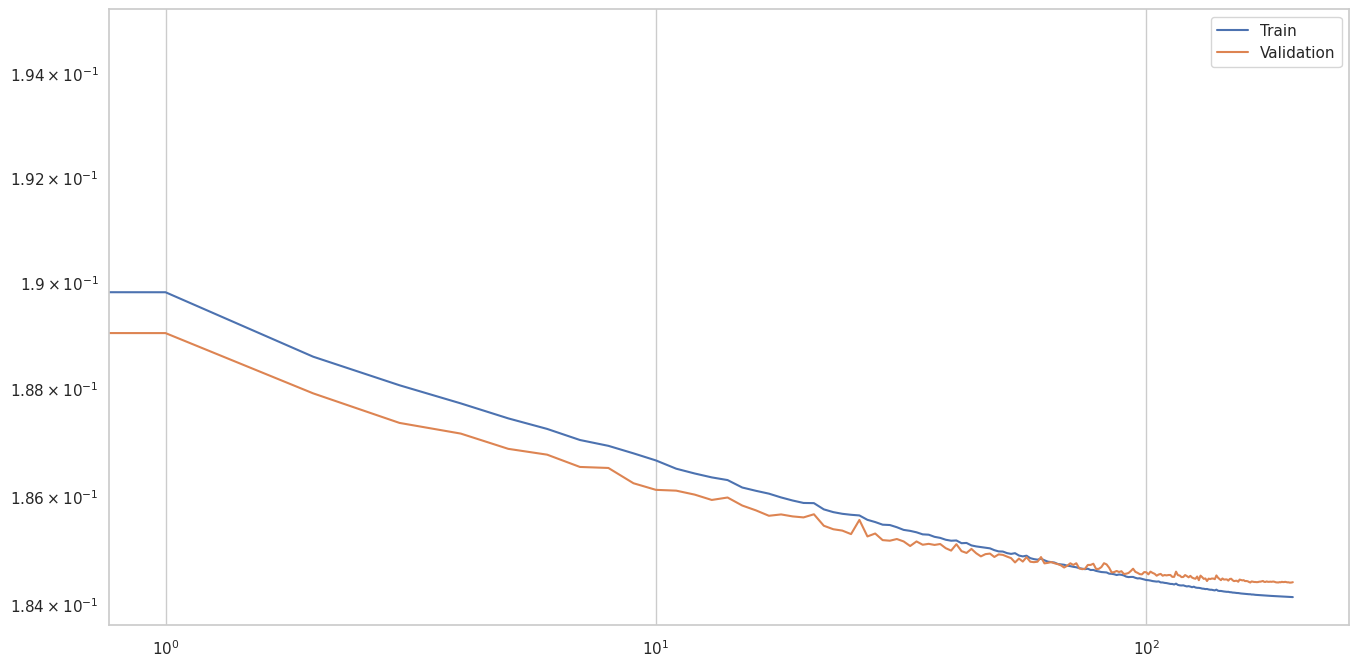

In [36]:
# plotting the loss curves
fig, axs = plt.subplots(1, figsize=(16, 8))
axs.loglog(history_train, label="Train")
axs.loglog(history_valid, label="Validation")
plt.legend()
plt.show()

In [37]:
y_pred_probs = ANN(X_test_array, params)
print('AUC Score:', (roc_auc_score(y_test_array, y_pred_probs)))

AUC Score: 0.8594199694885478


## Random Forest

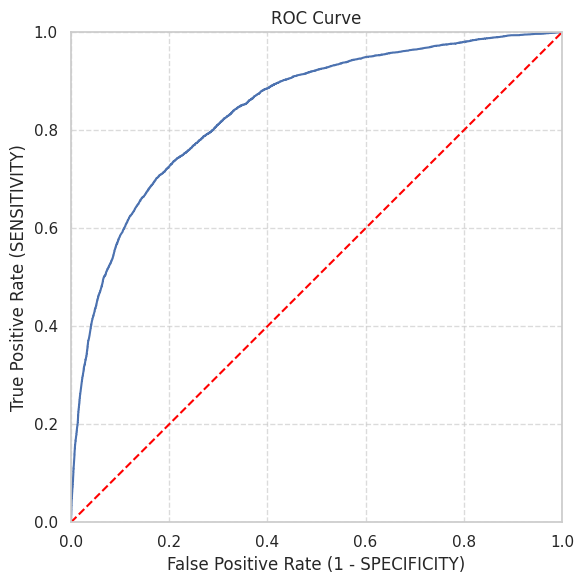

AUC Score: 0.8443090463448919


In [38]:
clf = RandomForestClassifier(random_state=123, max_depth=3, n_estimators=300, class_weight='balanced')
clf.fit(X_train_scaled, y_train)
clf_scores_proba = clf.predict_proba(X_train_scaled)
clf_preds = clf_scores_proba[:, 1]
fpr, tpr, thresh = roc_curve(y_train, clf_preds)
plot_roc_curve(fpr,tpr)
print('AUC Score:', (roc_auc_score(y_train, clf_preds)))

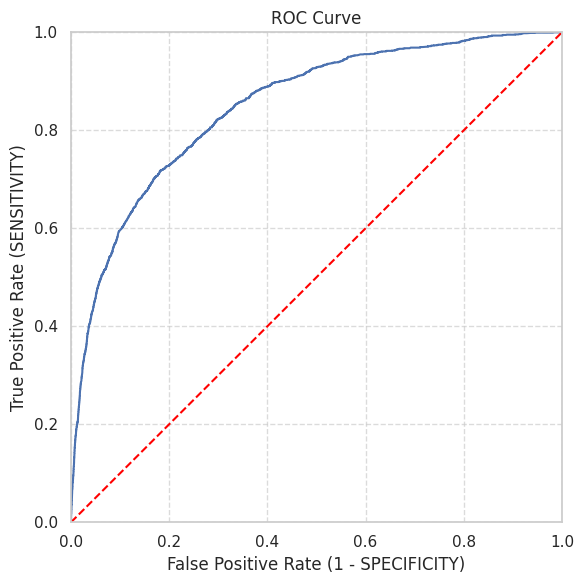

AUC Score: 0.8493744189504788


In [39]:
clf_scores_proba = clf.predict_proba(X_test_scaled)
clf_preds = clf_scores_proba[:, 1]
fpr, tpr, threshold = roc_curve(y_test, clf_preds)
plot_roc_curve(fpr, tpr)
print('AUC Score:', roc_auc_score(y_test, clf_preds))

## XG Boost

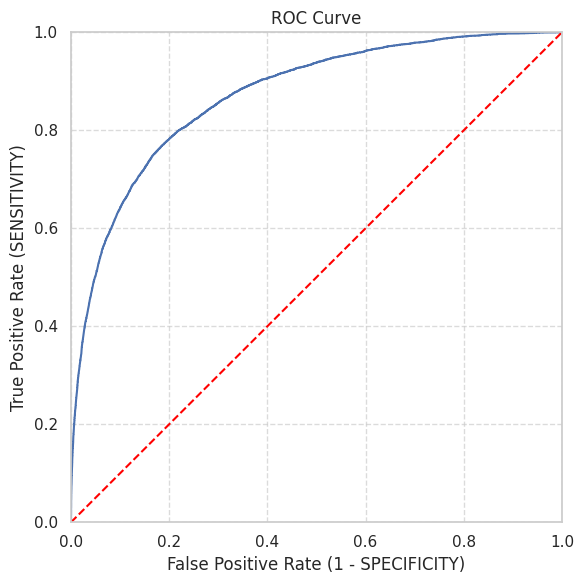

AUC Score: 0.8715632756884413


In [40]:
clf = XGBClassifier(random_state=123, n_estimators=150, learning_rate=0.05, max_depth=5)
clf.fit(X_train_scaled, y_train)
clf_scores_proba = clf.predict_proba(X_train_scaled)
# clf_scores_proba is a matrix with 2 columns (first one: probability that the sample
# belongs to class 0, second one: probability that the sample belongs to class 1)
clf_preds = clf_scores_proba[:, 1]
fpr, tpr, thresh = roc_curve(y_train, clf_preds)
# roc_curve returns 3 arrays: False Positive Rate (=FP/(FP+TN)), True Positive Rate (=TP/(TP+FN))
# and the thresholds that have been tested
plot_roc_curve(fpr, tpr)
print('AUC Score:', (roc_auc_score(y_train, clf_preds)))

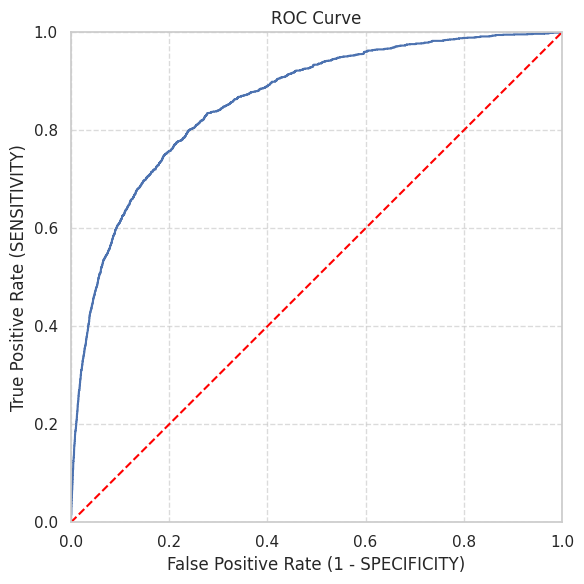

AUC Score: 0.8600281123660176
Accuracy: 93.52%


In [41]:
clf_scores_proba = clf.predict_proba(X_test_scaled)
clf_preds = clf_scores_proba[:, 1]
fpr, tpr, thresh = roc_curve(y_test, clf_preds)
plot_roc_curve(fpr, tpr)
print('AUC Score:', roc_auc_score(y_test, clf_preds))

y_pred = clf.predict(X_test_scaled)
preds = [round(value) for value in y_pred]
# round() because they're continuous values
accuracy = accuracy_score(y_test, preds)
print("Accuracy: %.2f%%" % (accuracy * 100.0))